### Assignment 2 (4 scores):

- Use Numpy only to construct the Sofmax Regression model.
- Train that Logistic Regression model dataset using the Gradient Descend approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

In [165]:
import pandas as pd
import numpy as np 


In [166]:
df = pd.read_csv('data.csv', sep = ';')  


In [142]:
df.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

# Preprocessing data

In [167]:
# Normalize discrete data by one-hot encoding
def encode_target (value: str) -> int:
    if value == 'Enrolled':
        return 0
    elif value == 'Dropout':
        return 1
    else:
        return 2

In [168]:
df['Target'] = df['Target'].apply(encode_target)

In [145]:
df.isna().sum(axis=0)

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [120]:
df.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2


# Normalization

In [169]:
continuous_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]
for column in continuous_features:
    df[column] = (df[column] - df[column].mean()) / df[column].std()

In [170]:
df.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,-0.804750,1,19,12,...,0,0,0,0,0.000000,0,-0.287606,0.124372,0.765674,1
1,1,15,1,9254,1,1,2.076585,1,1,3,...,0,6,6,6,13.666667,0,0.876123,-1.105097,0.347160,2
2,1,1,5,9070,1,1,-0.804750,1,37,37,...,0,6,0,0,0.000000,0,-0.287606,0.124372,0.765674,1
3,1,17,2,9773,1,1,-0.804750,1,38,37,...,0,6,10,5,12.400000,0,-0.813161,-1.466705,-1.375356,2
4,2,39,1,8014,0,1,-2.472892,1,37,38,...,0,6,6,6,13.000000,0,0.876123,-1.105097,0.347160,2


In [122]:
df.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [171]:
num_features = len(df.columns) - 1
# Create a correlation matrix (n x n)
cov = np.zeros((num_features, num_features))

# Calculate correlation matrix
cov = df.iloc[:, :-1].corr()
print('Correlation matric: \n', cov)


Correlation matric: 
                                                 Marital status  \
Marital status                                        1.000000   
Application mode                                      0.264006   
Application order                                    -0.125854   
Course                                                0.046365   
Daytime/evening attendance\t                         -0.274939   
Previous qualification                                0.062529   
Previous qualification (grade)                       -0.022406   
Nacionality                                          -0.008843   
Mother's qualification                                0.193163   
Father's qualification                                0.130353   
Mother's occupation                                   0.034994   
Father's occupation                                   0.031609   
Admission grade                                      -0.004771   
Displaced                                            -

/Users/nanhs/Documents/2nd_Semester(2024-2024)/DS102_StatisticalMachineLearning/Lab_02/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


<Axes: >

/Users/nanhs/Documents/2nd_Semester(2024-2024)/DS102_StatisticalMachineLearning/Lab_02/.venv/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/nanhs/Documents/2nd_Semester(2024-2024)/DS102_StatisticalMachineLearning/Lab_02/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


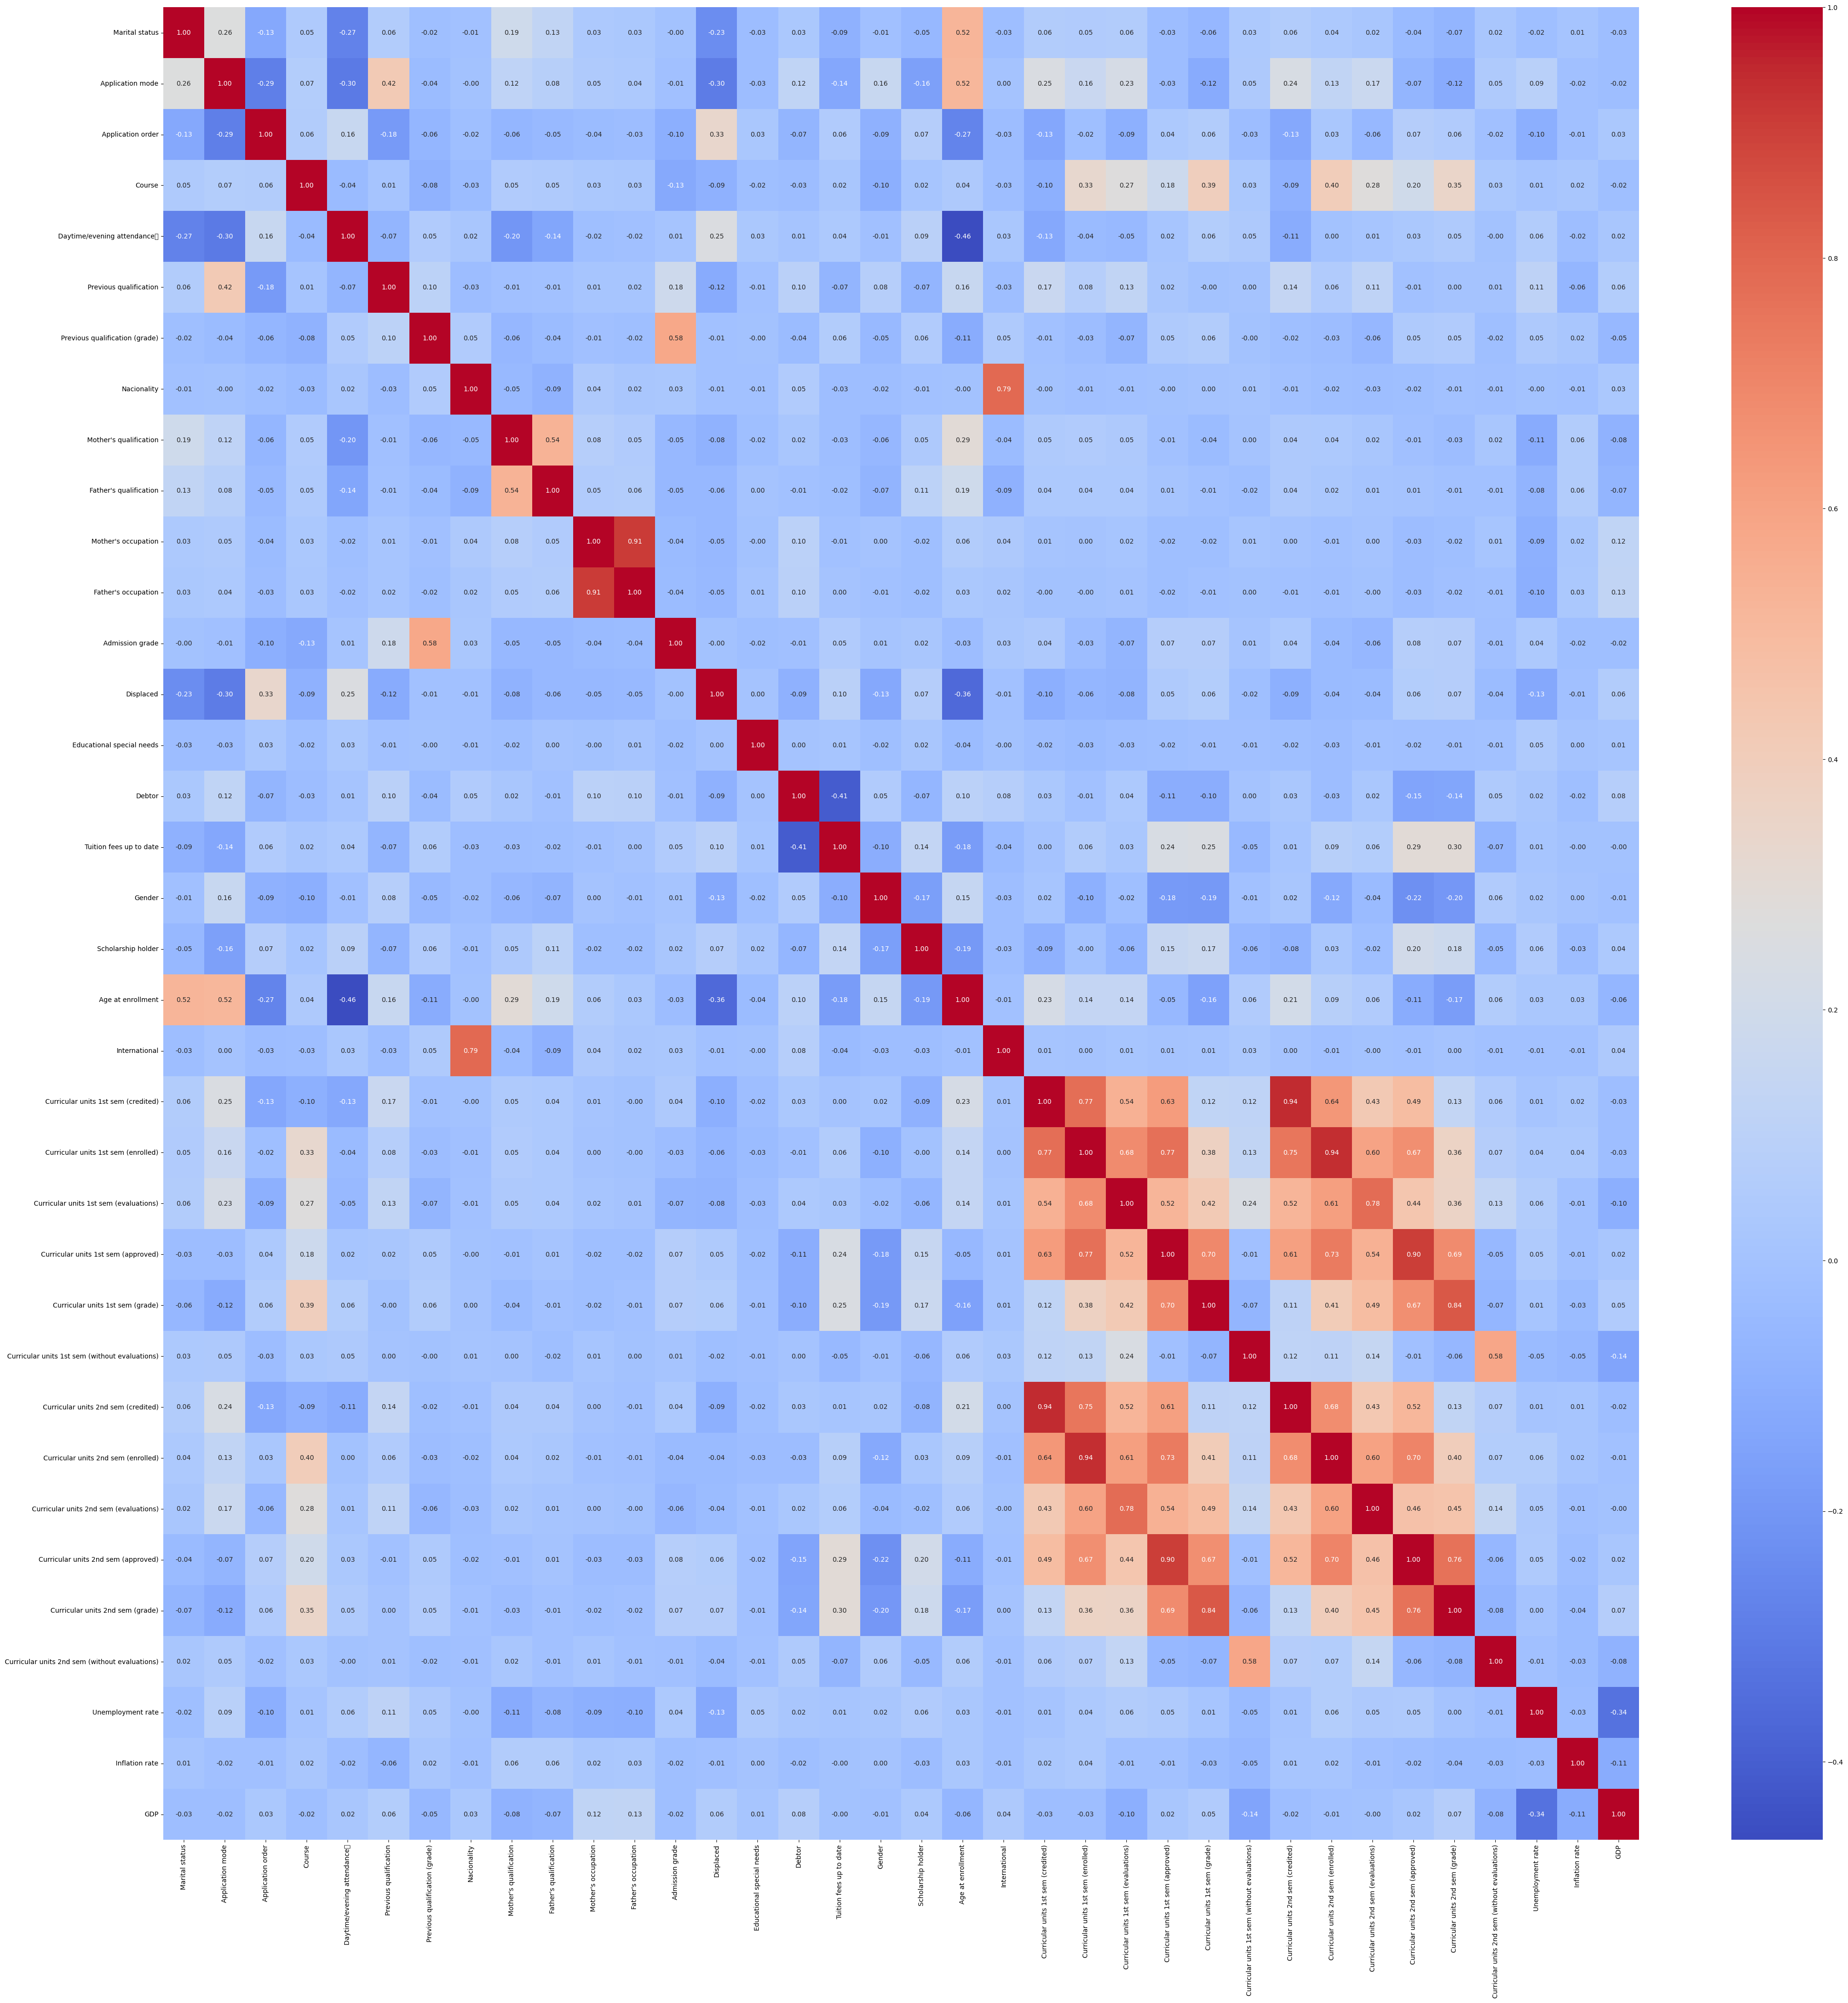

In [172]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(50,50))

sns.heatmap(cov, xticklabels=df.columns[:-1], yticklabels=df.columns[:-1],annot=cov, cmap='coolwarm', fmt='.2f')



In [173]:
# Select pairs with high correlation rate
corr_pairs = cov.unstack()
strong_corr = corr_pairs[(corr_pairs >= 0.8)]


In [174]:
strong_corr = strong_corr.reset_index()
strong_corr.columns = ['Feature 1', 'Feature 2', 'Correlation rate']
strong_corr =  strong_corr[strong_corr['Feature 1'] < strong_corr['Feature 2']]

In [175]:
strong_corr.head()

,Feature 1,Feature 2,Correlation rate
12,Father's occupation,Mother's occupation,0.910472
24,Curricular units 1st sem (credited),Curricular units 2nd sem (credited),0.944811
26,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.942627
29,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.904002
31,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),0.837170


In [176]:
column_to_drop = strong_corr['Feature 1']
df_reduced = df.drop(columns=column_to_drop)
df_reduced.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,-0.804750,1,19,12,...,0,0,0,0,0.000000,0,-0.287606,0.124372,0.765674,1
1,1,15,1,9254,1,1,2.076585,1,1,3,...,0,6,6,6,13.666667,0,0.876123,-1.105097,0.347160,2
2,1,1,5,9070,1,1,-0.804750,1,37,37,...,0,6,0,0,0.000000,0,-0.287606,0.124372,0.765674,1
3,1,17,2,9773,1,1,-0.804750,1,38,37,...,0,6,10,5,12.400000,0,-0.813161,-1.466705,-1.375356,2
4,2,39,1,8014,0,1,-2.472892,1,37,38,...,0,6,6,6,13.000000,0,0.876123,-1.105097,0.347160,2


In [177]:
x = df_reduced.iloc[:, :-1]
x.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,-0.804750,1,19,12,...,0,0,0,0,0,0.000000,0,-0.287606,0.124372,0.765674
1,1,15,1,9254,1,1,2.076585,1,1,3,...,0,0,6,6,6,13.666667,0,0.876123,-1.105097,0.347160
2,1,1,5,9070,1,1,-0.804750,1,37,37,...,0,0,6,0,0,0.000000,0,-0.287606,0.124372,0.765674
3,1,17,2,9773,1,1,-0.804750,1,38,37,...,0,0,6,10,5,12.400000,0,-0.813161,-1.466705,-1.375356
4,2,39,1,8014,0,1,-2.472892,1,37,38,...,0,0,6,6,6,13.000000,0,0.876123,-1.105097,0.347160


In [178]:
y = df_reduced.iloc[:, -1]
y.head()

0    1
1    2
2    1
3    2
4    2
Name: Target, dtype: int64

In [131]:
x = x.to_numpy()
x.shape

(4424, 31)

In [179]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [180]:
y = y.to_numpy()
# Convert "Target" into one-hot encoding
sh_y = np.zeros((y.shape[0], 3))
for i in range(y.shape[0]):
    sh_y[i, y[i]] = 1

In [181]:
y = y.reshape(-1, 1)

# Divide dataset into 3 sections:
- Train set: 80%
- Dev: 10%
- Test: 10%

In [182]:
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(x_scaled, sh_y, test_size=0.2, random_state=42, stratify=y)
x_dev, x_test, y_dev, y_test = train_test_split(x_temp, y_temp, test_size=0.5,random_state=42, stratify=y_temp)

print(f'Train set: {x_train.shape}, {y_train.shape}')
print(f'Dev set: {x_dev.shape}, {y_dev.shape}')
print(f'Test set: {x_test.shape}, {y_test.shape}')


Train set: (3539, 31), (3539, 3)
Dev set: (442, 31), (442, 3)
Test set: (443, 31), (443, 3)


In [183]:
from tqdm import tqdm

class SoftmaxRegression:
    def __init__(self, epoch: int, lr: int) -> None:
        self.epoch = epoch
        self.lr = lr
        self.losses = []
        self.matrix = []
    
    def softmax(self, z: np.ndarray) -> np.ndarray:
        exp_scores = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    
    def loss_fn(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        eps = 1e-9
        return -(y * np.log(y_hat + eps)).sum(axis=1).mean()
    
    def accuracy(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        return (np.argmax(y, axis=1) == np.argmax(y_hat, axis=1)).mean()
    
    def fit(self, x: np.ndarray, y: np.ndarray) -> None:
        n, d = x.shape
        n_classes = y.shape[1]
        
        x = np.hstack([np.ones((n, 1)), x]) # add bias to x
        self.theta = np.zeros((d + 1, n_classes))
        
        with tqdm(range(self.epoch)) as pb:
            for e in pb:
                pb.set_description(f'Epoch {e + 1}')
                s = self.predict(x)
                s = np.array(s)
                if s.shape != y.shape:
                    raise ValueError(f'Shape mismatch: s.shape = {s.shape}, y.shape = {y.shape}')
                # Find gradient and update theta
                gradient = (1 / n) * np.matmul(x.T, (s - y))
                self.theta -= self.lr * gradient
                loss = self.loss_fn(y, s)
                acc = self.accuracy(y, s)
                pb.set_postfix ({
                    'Loss ': loss,
                    'Acc ': acc
                })
                
                self.losses.append(loss)
                self.matrix.append(acc)
    
    def predict(self, x: np.ndarray) -> np.ndarray:
        if x.shape[1] == self.theta.shape[0] - 1:
            x = np.hstack([np.ones((x.shape[0], 1)), x])
        p = self.softmax(np.dot(x, self.theta))
        return np.asarray(p)
    
    def predict_classes(self, x: np.ndarray) -> np.ndarray:
        if x.shape[1] == self.theta.shape[0] - 1:
            x = np.hstack([np.ones((x.shape[0], 1)), x])
        return np.argmax(self.predict(x), axis=1)
                
                

In [184]:
softmax_reg = SoftmaxRegression(500, 0.001)

In [185]:
softmax_reg.fit(x_train, y_train)

Epoch 2:   0%|          | 0/500 [00:00<?, ?it/s, Loss =1.1, Acc =0.179]

Epoch 500: 100%|██████████| 500/500 [00:08<00:00, 56.32it/s, Loss =0.898, Acc =0.708]


In [186]:
# Predict for train set
y_pred = softmax_reg.predict(x_train)
acc = softmax_reg.accuracy(y_train, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")


Test Accuracy: 0.7078


In [187]:
# Predict for test set
y_pred = softmax_reg.predict(x_test)
acc = softmax_reg.accuracy(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")


Test Accuracy: 0.7133


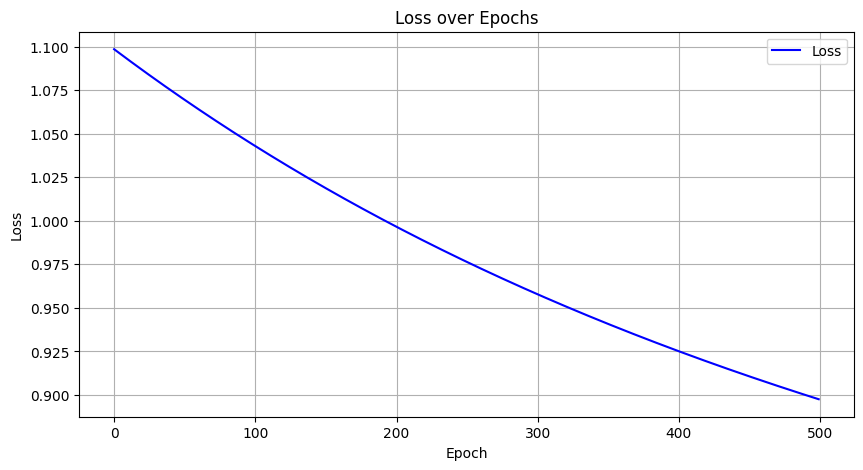

In [188]:
import matplotlib.pyplot as plt

# After training
plt.figure(figsize=(10, 5))
plt.plot(softmax_reg.losses, label='Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()
